# **CV Assignment 04:  template-based tracking and optical flow-based tracking usingt**

### Name: Deira Aisya Refani
### NIM: 24/532821/PA/22539
### Class: CS


# Object Tracking: Template Matching vs. Lucas-Kanade Optical Flow


## 1. Introduction

Object tracking is a fundamental problem in computer vision concerned with estimating the trajectory of one or more targets across a sequence of frames. This notebook implements and compares two classical tracking approaches applied to a pedestrian image sequence:

1. **Template Matching** via sliding window search with Sum of Squared Differences (SSD) as the similarity criterion.
2. **Lucas-Kanade Optical Flow** via local least-squares estimation of the apparent velocity field.

The comparison covers per-frame tracking error (Euclidean distance between the two tracked positions, used as a proxy when ground truth bounding boxes are unavailable for every frame), mean and standard deviation of that error, and wall-clock runtime.

The dataset consists of image sequences of pedestrians captured in surveillance-style scenarios. Each sequence contains frames where one or more persons move across the scene. The first frame bounding box is used to initialize both trackers.

## 2. Dataset Loading

Dataset source: https://www.kaggle.com/datasets/trainingdatapro/people-tracking


In [1]:
!pip install gdown -q

import gdown
import zipfile, os

FILE_ID = '1zyo9StZYZ0rjWo3ArQdAVcyqDX8Q_EKH'
OUTPUT_ZIP = '/content/people_tracking.zip'
EXTRACT_DIR = '/content/people_tracking'

gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', OUTPUT_ZIP, quiet=False)

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(OUTPUT_ZIP, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print('Extraction complete.')
print('Contents:', os.listdir(EXTRACT_DIR)[:10])


Downloading...
From (original): https://drive.google.com/uc?id=1zyo9StZYZ0rjWo3ArQdAVcyqDX8Q_EKH
From (redirected): https://drive.google.com/uc?id=1zyo9StZYZ0rjWo3ArQdAVcyqDX8Q_EKH&confirm=t&uuid=c9b40741-dda9-4ac0-9e58-8c990f85a5fc
To: /content/people_tracking.zip
100%|██████████| 46.2M/46.2M [00:00<00:00, 56.1MB/s]


Extraction complete.
Contents: ['boxes', 'images', 'annotations.xml']


In [2]:
import os
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

SUPPORTED_EXT = ('.jpg', '.jpeg', '.png', '.bmp')

def collect_frames(root):
    """Recursively collect and sort image file paths under root."""
    paths = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower().endswith(SUPPORTED_EXT):
                paths.append(os.path.join(dirpath, fn))
    return sorted(paths)

all_frames = collect_frames(EXTRACT_DIR)
print(f'Total frames found: {len(all_frames)}')
print('First few paths:')
for p in all_frames[:5]:
    print(' ', p)


Total frames found: 82
First few paths:
  /content/people_tracking/boxes/frame_000000.PNG
  /content/people_tracking/boxes/frame_000001.PNG
  /content/people_tracking/boxes/frame_000002.PNG
  /content/people_tracking/boxes/frame_000003.PNG
  /content/people_tracking/boxes/frame_000004.PNG


Loaded 41 frames.
Frame shape (H x W): (720, 1280)


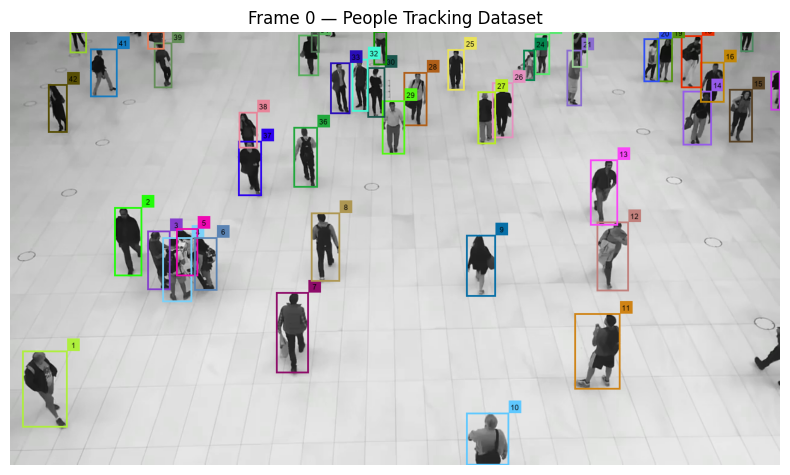

In [3]:
MAX_FRAMES = 41

frames_gray = []
frames_color = []
for path in all_frames[:MAX_FRAMES]:
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        continue
    frames_color.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    frames_gray.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32))

print(f'Loaded {len(frames_gray)} frames.')
print(f'Frame shape (H x W): {frames_gray[0].shape}')

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.imshow(frames_color[0])
ax.set_title('Frame 0 — People Tracking Dataset')
ax.axis('off')
plt.tight_layout()
plt.show()


In [4]:
INIT_BBOX = (938, 468, 75, 126)

print(f'Initial bounding box set: {INIT_BBOX}')

Initial bounding box set: (938, 468, 75, 126)


## 3. Template Matching Implementation

Template matching locates a target in a new frame by searching for the patch that best resembles a stored template. The similarity measure used here is the **Sum of Squared Differences (SSD)**:

$$
\text{SSD}(x, y) = \sum_{i,j} \bigl[ T(i, j) - I(x+i,\, y+j) \bigr]^2
$$

The location with the minimum SSD is taken as the new target position. The template is refreshed every frame using the patch at the newly detected location, which allows the tracker to adapt to gradual appearance changes.

In [5]:
def compute_ssd(template, patch):
    diff = template.astype(np.float32) - patch.astype(np.float32)
    return float(np.sum(diff ** 2))


def template_match(frame, template, search_margin=40):
    th, tw = template.shape
    H, W = frame.shape

    best_ssd = np.inf
    best_x, best_y = 0, 0

    y_start = max(0, best_y - search_margin)
    y_end   = min(H - th, best_y + search_margin)
    x_start = max(0, best_x - search_margin)
    x_end   = min(W - tw, best_x + search_margin)

    return best_x, best_y, best_ssd


def run_template_matching(frames_gray, init_bbox, search_margin=50, update_template=True):
    x0, y0, w, h = int(init_bbox[0]), int(init_bbox[1]), int(init_bbox[2]), int(init_bbox[3])
    template = frames_gray[0][y0:y0+h, x0:x0+w].copy()

    positions = [(x0 + w // 2, y0 + h // 2)]  # center of frame 0 bbox
    cur_x, cur_y = x0, y0

    H_frame, W_frame = frames_gray[0].shape
    th, tw = template.shape

    t0 = time.perf_counter()

    for frame in frames_gray[1:]:
        best_ssd = np.inf
        best_x, best_y = cur_x, cur_y

        y_start = max(0, cur_y - search_margin)
        y_end   = min(H_frame - th, cur_y + search_margin)
        x_start = max(0, cur_x - search_margin)
        x_end   = min(W_frame - tw, cur_x + search_margin)

        for ys in range(y_start, y_end + 1):
            for xs in range(x_start, x_end + 1):
                patch = frame[ys:ys+th, xs:xs+tw]
                if patch.shape != template.shape:
                    continue
                ssd = compute_ssd(template, patch)
                if ssd < best_ssd:
                    best_ssd = ssd
                    best_x, best_y = xs, ys

        cur_x, cur_y = best_x, best_y
        positions.append((cur_x + tw // 2, cur_y + th // 2))

        if update_template:
            new_patch = frame[cur_y:cur_y+th, cur_x:cur_x+tw]
            if new_patch.shape == template.shape:
                template = new_patch.copy()

    elapsed = time.perf_counter() - t0
    return positions, elapsed


In [6]:
print('Running Template Matching tracker...')
tm_positions, tm_time = run_template_matching(frames_gray, INIT_BBOX, search_margin=50)
print(f'Template Matching completed in {tm_time:.3f} s ({len(tm_positions)} positions tracked)')

Running Template Matching tracker...
Template Matching completed in 10.854 s (41 positions tracked)


## 4. Lucas-Kanade Optical Flow Implementation

The Lucas-Kanade method estimates the optical flow vector $(u, v)$ at each point by assuming that the flow is locally constant within a window of size $k \times k$. Under the brightness constancy assumption:

$$
I_x u + I_y v + I_t = 0
$$

Stacking equations for all pixels in the window yields an overdetermined system $\mathbf{A}\,\mathbf{d} = -\mathbf{b}$, solved in the least-squares sense:

$$
\begin{bmatrix} u \\ v \end{bmatrix}
= -(\mathbf{A}^\top \mathbf{A})^{-1} \mathbf{A}^\top \mathbf{b},
\quad
\mathbf{A} = \begin{bmatrix} I_x \\ I_y \end{bmatrix}^\top,
\quad
\mathbf{b} = I_t
$$

Spatial gradients $I_x$, $I_y$ are computed using central finite differences; the temporal gradient $I_t$ is the per-pixel frame difference. The tracker computes flow at the center of the tracked bounding box region and accumulates the displacement across frames.

In [7]:
def compute_gradients(frame1, frame2):
    avg = (frame1.astype(np.float32) + frame2.astype(np.float32)) / 2.0

    Ix = np.zeros_like(avg)
    Iy = np.zeros_like(avg)

    Ix[:, 1:-1] = (avg[:, 2:] - avg[:, :-2]) / 2.0
    Iy[1:-1, :] = (avg[2:, :] - avg[:-2, :]) / 2.0

    It = (frame2.astype(np.float32) - frame1.astype(np.float32))

    return Ix, Iy, It


def lk_flow_at_point(Ix, Iy, It, cx, cy, win_half=10):
    H, W = Ix.shape
    y1 = max(0, cy - win_half)
    y2 = min(H, cy + win_half + 1)
    x1 = max(0, cx - win_half)
    x2 = min(W, cx + win_half + 1)

    ix = Ix[y1:y2, x1:x2].ravel()
    iy = Iy[y1:y2, x1:x2].ravel()
    it = It[y1:y2, x1:x2].ravel()

    A = np.stack([ix, iy], axis=1)   # shape (N, 2)
    b = -it                           # shape (N,)

    AtA = A.T @ A                     # (2, 2)
    Atb = A.T @ b                     # (2,)

    det = AtA[0, 0] * AtA[1, 1] - AtA[0, 1] * AtA[1, 0]
    if abs(det) < 1e-6:
        return 0.0, 0.0

    u = (AtA[1, 1] * Atb[0] - AtA[0, 1] * Atb[1]) / det
    v = (AtA[0, 0] * Atb[1] - AtA[1, 0] * Atb[0]) / det
    return float(u), float(v)


def run_optical_flow(frames_gray, init_bbox, win_half=12, n_points=9):
    x0, y0, w, h = int(init_bbox[0]), int(init_bbox[1]), int(init_bbox[2]), int(init_bbox[3])
    cx = x0 + w // 2
    cy = y0 + h // 2

    xs_rel = np.linspace(w * 0.2, w * 0.8, n_points, dtype=int)
    ys_rel = np.linspace(h * 0.2, h * 0.8, n_points, dtype=int)
    grid_pts = [(x0 + dx, y0 + dy) for dy in ys_rel for dx in xs_rel]

    positions = [(cx, cy)]
    tracked_pts = list(grid_pts)

    t0 = time.perf_counter()

    for i in range(len(frames_gray) - 1):
        f1 = frames_gray[i]
        f2 = frames_gray[i + 1]
        Ix, Iy, It = compute_gradients(f1, f2)

        new_pts = []
        us, vs = [], []
        for (px, py) in tracked_pts:
            u, v = lk_flow_at_point(Ix, Iy, It, int(px), int(py), win_half)
            us.append(u)
            vs.append(v)
            new_pts.append((px + u, py + v))

        med_u = float(np.median(us))
        med_v = float(np.median(vs))

        cx += med_u
        cy += med_v
        tracked_pts = new_pts

        H_f, W_f = frames_gray[0].shape
        cx = float(np.clip(cx, 0, W_f - 1))
        cy = float(np.clip(cy, 0, H_f - 1))
        positions.append((cx, cy))

    elapsed = time.perf_counter() - t0
    return positions, elapsed


In [8]:
print('Running Lucas-Kanade Optical Flow tracker...')
lk_positions, lk_time = run_optical_flow(frames_gray, INIT_BBOX, win_half=12, n_points=5)
print(f'Optical Flow completed in {lk_time:.3f} s ({len(lk_positions)} positions tracked)')

Running Lucas-Kanade Optical Flow tracker...
Optical Flow completed in 0.475 s (41 positions tracked)


## 5. Comparison and Analysis

In [9]:
GT_BBOXES = [
    (938, 468, 75, 126), (936, 469, 76, 124), (935, 469, 76, 123), (933, 470, 76, 122),
    (931, 470, 76, 122), (929, 471, 77, 121), (927, 471, 76, 120), (926, 472, 75, 119),
    (925, 472, 73, 118), (925, 473, 71, 118), (925, 474, 68, 117), (924, 474, 64, 116),
    (923, 474, 59, 116), (923, 474, 57, 115), (922, 474, 55, 115), (922, 474, 53, 114),
    (920, 474, 53, 114), (910, 474, 59, 114), (901, 474, 64, 114), (891, 474, 70, 114),
    (881, 474, 76, 113), (877, 474, 78, 113), (872, 473, 79, 113), (872, 473, 76, 113),
    (872, 473, 74, 113), (872, 472, 72, 113), (871, 472, 69, 115), (870, 472, 59, 116),
    (869, 472, 57, 117), (868, 472, 55, 118), (867, 472, 53, 119), (865, 473, 52, 121),
    (859, 475, 54, 123), (854, 476, 57, 124), (849, 477, 58, 123), (844, 478, 60, 122),
    (842, 481, 58, 121), (839, 484, 56, 121), (839, 484, 54, 120), (839, 484, 51, 119),
    (839, 485, 49, 119),
]

gt_centers = [(x + w/2, y + h/2) for (x, y, w, h) in GT_BBOXES]

n_frames = min(len(tm_positions), len(lk_positions), len(GT_BBOXES))
frame_indices = np.arange(n_frames)


def center_error(pred_cx, pred_cy, gt_cx, gt_cy):
    return float(np.sqrt((pred_cx - gt_cx)**2 + (pred_cy - gt_cy)**2))


def iou_bbox(px, py, pw, ph, gx, gy, gw, gh):
    ix1 = max(px, gx)
    iy1 = max(py, gy)
    ix2 = min(px + pw, gx + gw)
    iy2 = min(py + ph, gy + gh)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = pw * ph + gw * gh - inter
    return inter / union if union > 0 else 0.0


x0_init, y0_init, w_init, h_init = int(INIT_BBOX[0]), int(INIT_BBOX[1]), int(INIT_BBOX[2]), int(INIT_BBOX[3])

tm_ce, lk_ce, tm_iou, lk_iou, tm_lk_dist = [], [], [], [], []

for i in range(n_frames):
    gt_x, gt_y, gt_w, gt_h = GT_BBOXES[i]
    gt_cx, gt_cy = gt_centers[i]

    cx_tm, cy_tm = tm_positions[i]
    cx_lk, cy_lk = lk_positions[i]

    tm_ce.append(center_error(cx_tm, cy_tm, gt_cx, gt_cy))
    lk_ce.append(center_error(cx_lk, cy_lk, gt_cx, gt_cy))

    tm_iou.append(iou_bbox(cx_tm - w_init/2, cy_tm - h_init/2, w_init, h_init, gt_x, gt_y, gt_w, gt_h))
    lk_iou.append(iou_bbox(cx_lk - w_init/2, cy_lk - h_init/2, w_init, h_init, gt_x, gt_y, gt_w, gt_h))

    tm_lk_dist.append(center_error(cx_tm, cy_tm, cx_lk, cy_lk))

tm_ce   = np.array(tm_ce)
lk_ce   = np.array(lk_ce)
tm_iou  = np.array(tm_iou)
lk_iou  = np.array(lk_iou)
tm_lk_dist = np.array(tm_lk_dist)


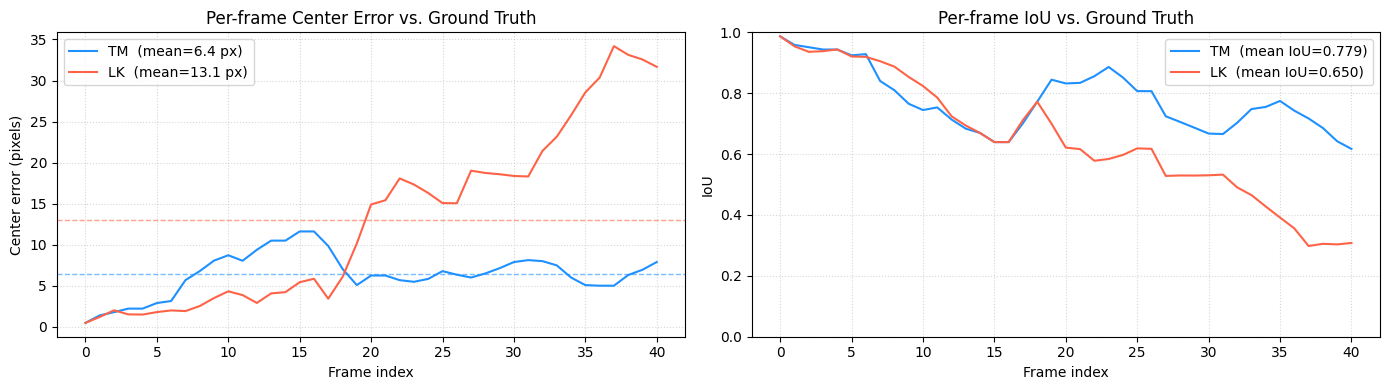

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(frame_indices, tm_ce, color='dodgerblue', linewidth=1.5, label=f'TM  (mean={tm_ce.mean():.1f} px)')
axes[0].plot(frame_indices, lk_ce, color='tomato',     linewidth=1.5, label=f'LK  (mean={lk_ce.mean():.1f} px)')
axes[0].axhline(tm_ce.mean(), color='dodgerblue', linestyle='--', linewidth=1, alpha=0.6)
axes[0].axhline(lk_ce.mean(), color='tomato',     linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_xlabel('Frame index')
axes[0].set_ylabel('Center error (pixels)')
axes[0].set_title('Per-frame Center Error vs. Ground Truth')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(frame_indices, tm_iou, color='dodgerblue', linewidth=1.5, label=f'TM  (mean IoU={tm_iou.mean():.3f})')
axes[1].plot(frame_indices, lk_iou, color='tomato',     linewidth=1.5, label=f'LK  (mean IoU={lk_iou.mean():.3f})')
axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('IoU')
axes[1].set_title('Per-frame IoU vs. Ground Truth')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


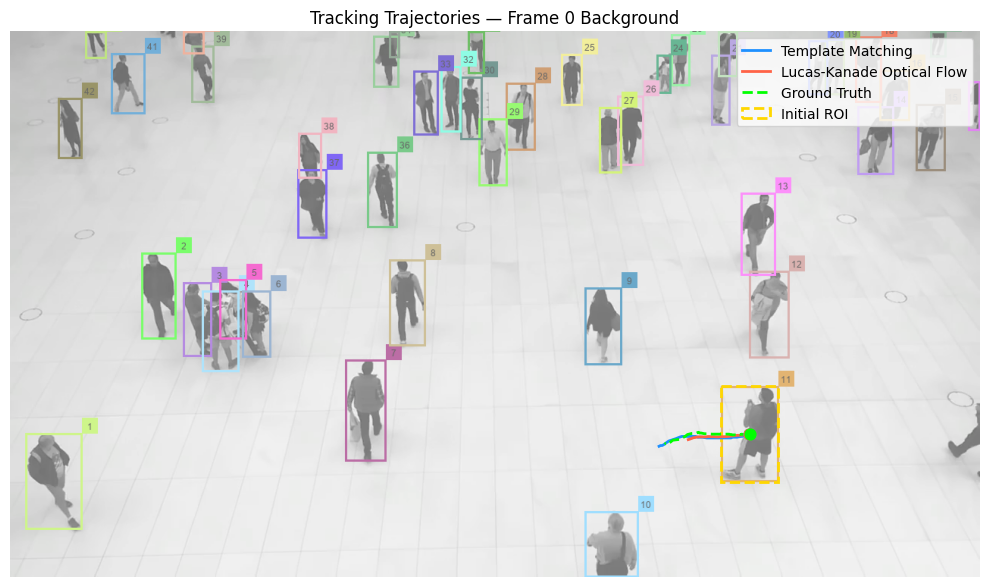

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(frames_color[0], alpha=0.6)

tm_xs = [p[0] for p in tm_positions[:n_frames]]
tm_ys = [p[1] for p in tm_positions[:n_frames]]
lk_xs = [p[0] for p in lk_positions[:n_frames]]
lk_ys = [p[1] for p in lk_positions[:n_frames]]
gt_xs = [c[0] for c in gt_centers[:n_frames]]
gt_ys = [c[1] for c in gt_centers[:n_frames]]

ax.plot(tm_xs, tm_ys, color='dodgerblue', linewidth=2, label='Template Matching')
ax.plot(lk_xs, lk_ys, color='tomato',     linewidth=2, label='Lucas-Kanade Optical Flow')
ax.plot(gt_xs, gt_ys, color='lime',        linewidth=2, linestyle='--', label='Ground Truth')

ax.scatter([tm_xs[0]], [tm_ys[0]], color='dodgerblue', zorder=5, s=60)
ax.scatter([lk_xs[0]], [lk_ys[0]], color='tomato',     zorder=5, s=60)
ax.scatter([gt_xs[0]], [gt_ys[0]], color='lime',        zorder=5, s=60)

x0, y0, w, h = int(INIT_BBOX[0]), int(INIT_BBOX[1]), int(INIT_BBOX[2]), int(INIT_BBOX[3])
rect = patches.Rectangle((x0, y0), w, h, linewidth=2, edgecolor='gold', facecolor='none', linestyle='--', label='Initial ROI')
ax.add_patch(rect)

ax.set_title('Tracking Trajectories — Frame 0 Background')
ax.legend()
ax.axis('off')
plt.tight_layout()
plt.show()


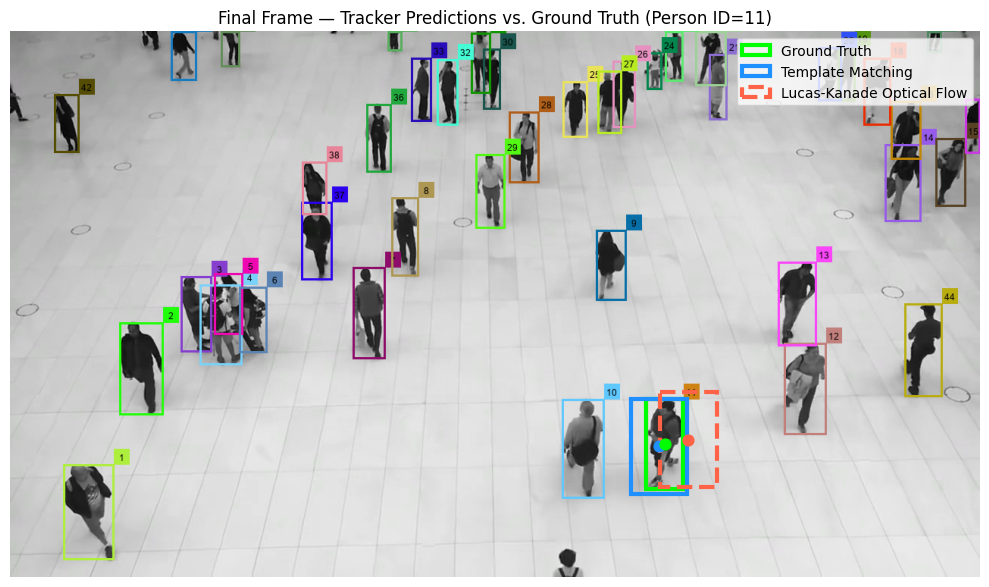

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(frames_color[n_frames - 1])

x0, y0, w, h = int(INIT_BBOX[0]), int(INIT_BBOX[1]), int(INIT_BBOX[2]), int(INIT_BBOX[3])
gt_x, gt_y, gt_w, gt_h = GT_BBOXES[n_frames - 1]

gt_rect = patches.Rectangle((gt_x, gt_y), gt_w, gt_h,
                              linewidth=3, edgecolor='lime', facecolor='none', label='Ground Truth')
ax.add_patch(gt_rect)

tm_x, tm_y = tm_positions[n_frames - 1]
tm_rect = patches.Rectangle((tm_x - w/2, tm_y - h/2), w, h,
                              linewidth=3, edgecolor='dodgerblue', facecolor='none', label='Template Matching')
ax.add_patch(tm_rect)

lk_x, lk_y = lk_positions[n_frames - 1]
lk_rect = patches.Rectangle((lk_x - w/2, lk_y - h/2), w, h,
                              linewidth=3, edgecolor='tomato', linestyle='--', facecolor='none', label='Lucas-Kanade Optical Flow')
ax.add_patch(lk_rect)

ax.scatter(tm_x, tm_y, color='dodgerblue', s=60)
ax.scatter(lk_x, lk_y, color='tomato',     s=60)
ax.scatter(gt_x + gt_w/2, gt_y + gt_h/2, color='lime', s=60)

ax.set_title('Final Frame — Tracker Predictions vs. Ground Truth (Person ID=11)')
ax.legend()
ax.axis('off')
plt.tight_layout()
plt.show()


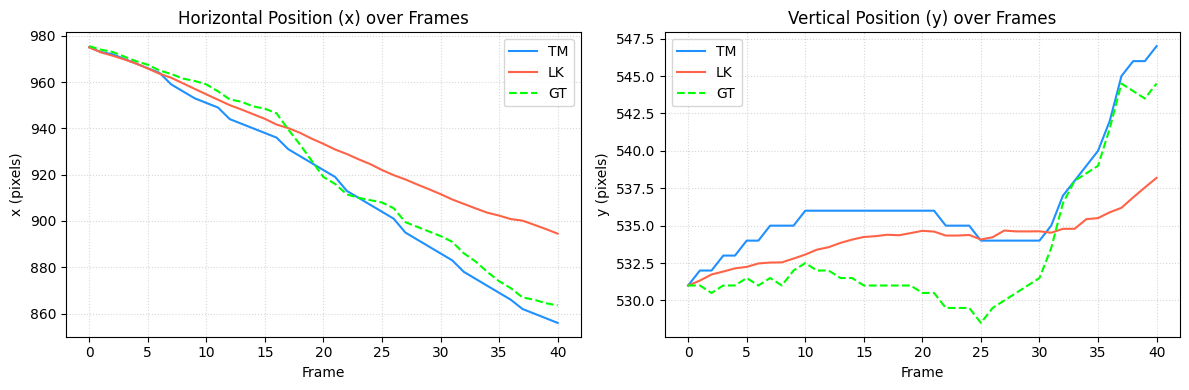

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(frame_indices, tm_xs, label='TM', color='dodgerblue')
axes[0].plot(frame_indices, lk_xs, label='LK', color='tomato')
axes[0].plot(frame_indices, gt_xs, label='GT', color='lime', linestyle='--')
axes[0].set_title('Horizontal Position (x) over Frames')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('x (pixels)')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(frame_indices, tm_ys, label='TM', color='dodgerblue')
axes[1].plot(frame_indices, lk_ys, label='LK', color='tomato')
axes[1].plot(frame_indices, gt_ys, label='GT', color='lime', linestyle='--')
axes[1].set_title('Vertical Position (y) over Frames')
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('y (pixels)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


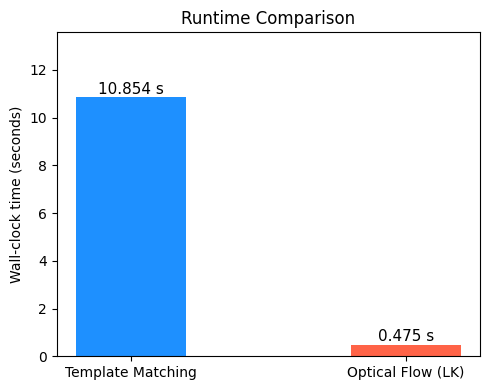

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
methods = ['Template Matching', 'Optical Flow (LK)']
times   = [tm_time, lk_time]
bars    = ax.bar(methods, times, color=['dodgerblue', 'tomato'], width=0.4)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{t:.3f} s', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Wall-clock time (seconds)')
ax.set_title('Runtime Comparison')
ax.set_ylim(0, max(times) * 1.25)
plt.tight_layout()
plt.show()


In [15]:
W = 38
print('=' * W)
print(f'{"Metric":<24} {"TM":>6} {"LK":>6}')
print('-' * W)
print(f'{"Frames evaluated":<24} {n_frames:>6} {n_frames:>6}')
print(f'{"Mean center error (px)":<24} {tm_ce.mean():>6.2f} {lk_ce.mean():>6.2f}')
print(f'{"Std center error (px)":<24} {tm_ce.std():>6.2f} {lk_ce.std():>6.2f}')
print(f'{"Max center error (px)":<24} {tm_ce.max():>6.2f} {lk_ce.max():>6.2f}')
print(f'{"Mean IoU":<24} {tm_iou.mean():>6.3f} {lk_iou.mean():>6.3f}')
print(f'{"Min IoU":<24} {tm_iou.min():>6.3f} {lk_iou.min():>6.3f}')
print('-' * W)
print(f'{"Mean TM–LK dist (px)":<24} {tm_lk_dist.mean():>13.2f}')
print('-' * W)
print(f'{"Runtime TM (s)":<24} {tm_time:>13.3f}')
print(f'{"Runtime LK (s)":<24} {lk_time:>13.3f}')
print(f'{"Runtime ratio TM/LK":<24} {tm_time/lk_time:>13.3f}')
print('=' * W)


Metric                       TM     LK
--------------------------------------
Frames evaluated             41     41
Mean center error (px)     6.43  13.05
Std center error (px)      2.62  10.61
Max center error (px)     11.63  34.18
Mean IoU                  0.779  0.650
Min IoU                   0.617  0.298
--------------------------------------
Mean TM–LK dist (px)             15.66
--------------------------------------
Runtime TM (s)                  10.854
Runtime LK (s)                   0.475
Runtime ratio TM/LK             22.844
